In [1]:
import numpy as np
from matplotlib import pyplot as plt
from convert import load_depth, load_image
from stereo import compute_depth
import os
import cv2

PATH = "//wsl.localhost/Ubuntu/home/wyatt/CameraSimData"
N = 10

EOFError: Ran out of input

In [ ]:
depth = load_depth(os.path.join(PATH,"depth"), N)
left = load_image(os.path.join(PATH, "left"), N)
right = load_image(os.path.join(PATH, "right"), N)


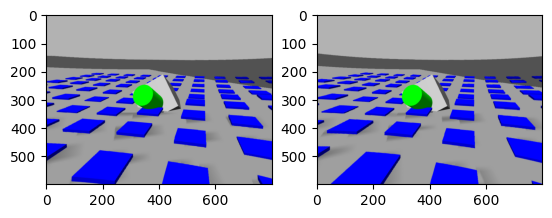

In [ ]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(left)
ax[1].imshow(right)

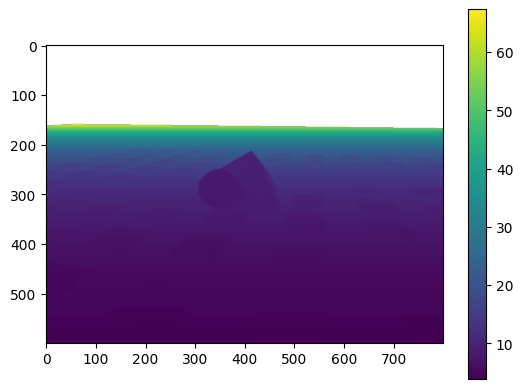

In [ ]:
plt.imshow(depth)
plt.colorbar()

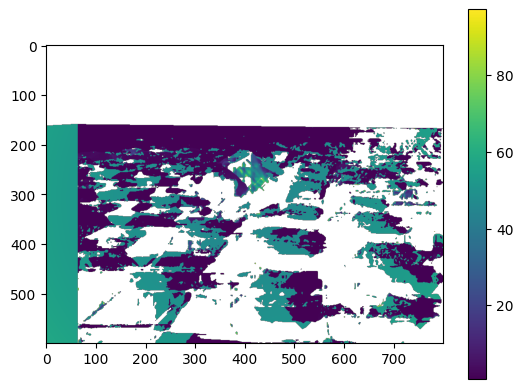

In [ ]:
depth_est = compute_depth(
    np.mean(left, axis=2).astype(np.uint8), 
    np.mean(right, axis=2).astype(np.uint8)
) / 100
depth_est[np.isinf(depth)] = np.inf
plt.imshow(depth_est)
plt.colorbar()

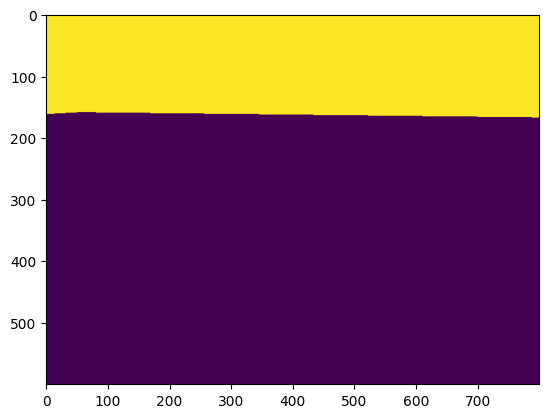

In [ ]:

mask = np.isinf(depth)
plt.imshow(mask)
mask = mask.flatten()

C:\Users\wyatt\AppData\Local\Temp\ipykernel_23896\935694059.py:2: RuntimeWarning: invalid value encountered in divide
  diff = ((depth_est - depth) / (depth + 1e-9)).flatten()


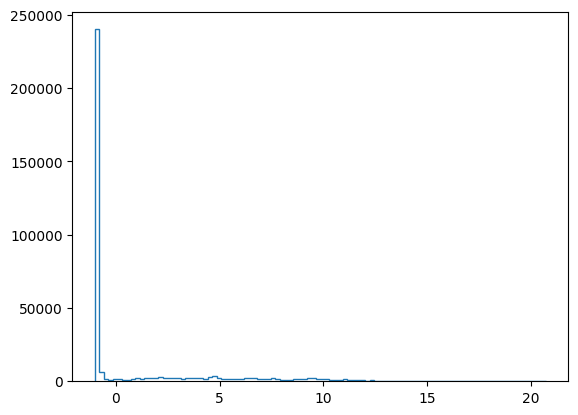

Mean error 94%, std. deviation 348.79998779296875%


In [ ]:
depth_est[np.isinf(depth_est)] = 0
diff = ((depth_est - depth) / (depth + 1e-9)).flatten()
err = [diff[i] for i in range(len(diff)) if not mask[i]]
counts, bins = np.histogram(err, 100)
plt.stairs(counts, bins)
plt.show()
print(f"Mean error {round(np.mean(err) * 100)}%, std. deviation {round(np.std(err)*100, 2)}%")

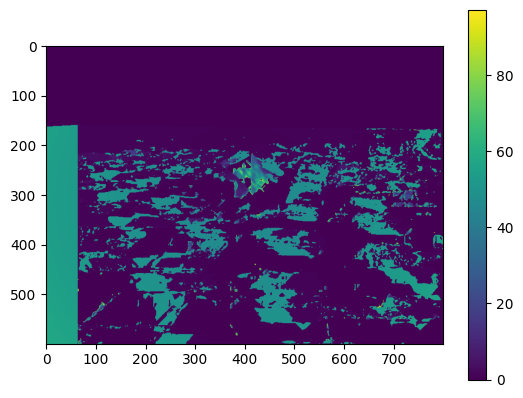

In [ ]:
depth_filled = cv2.inpaint(depth_est, np.isinf(depth_est).astype(np.uint8), 5, cv2.INPAINT_TELEA)
plt.imshow(depth_filled)
plt.colorbar()

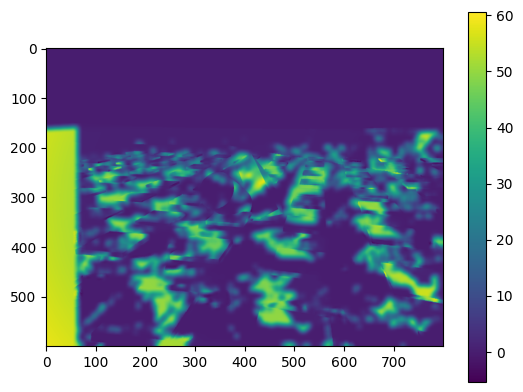

In [ ]:
depth_filtered = cv2.ximgproc.guidedFilter(np.mean(left, axis=2).astype(np.float32) / 255, depth_filled, 5, 1e-6)
plt.imshow(depth_filtered)
plt.colorbar()

C:\Users\wyatt\AppData\Local\Temp\ipykernel_23896\21361202.py:1: RuntimeWarning: invalid value encountered in divide
  diff = ((depth_filtered - depth) / (depth + 1e-9)).flatten()


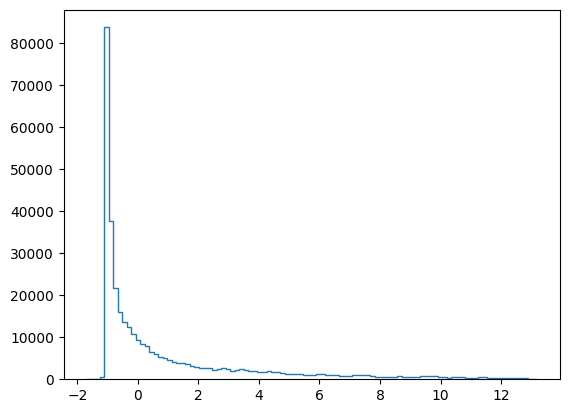

Mean error 94%, std. deviation 284.32000732421875%


In [ ]:
diff = ((depth_filtered - depth) / (depth + 1e-9)).flatten()
err = [diff[i] for i in range(len(diff)) if not mask[i]]
counts, bins = np.histogram(err, 100)
plt.stairs(counts, bins)
plt.show()
print(f"Mean error {round(np.mean(err) * 100)}%, std. deviation {round(np.std(err)*100, 2)}%")